In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import random
from collections import deque
from snakeGameVAI import SnakeGameAI, WIDTH, HEIGHT, GRID_SIZE
import os
import pygame

pygame 2.6.1 (SDL 2.28.4, Python 3.10.19)
Hello from the pygame community. https://www.pygame.org/contribute.html


m:\anaconda\envs\alex\lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
class SnakeDQN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(11, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 4)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)

In [3]:
class Agent:
    def __init__(self):
        self.n_games = 0
        self.epsilon = 1.0  # Randomness
        self.gamma = 0.9    # Discount rate
        self.memory = deque(maxlen=100_000)
        self.record = 0
        self.model = SnakeDQN().to('cuda') # Move to your 4060
        self.optimizer = optim.Adam(self.model.parameters(), lr=0.001)
        self.criterion = nn.MSELoss()
        self.model_path = 'model/snake_dqn.pth'
        self.load_model()
    
    def save_model(self):
        """Save model, optimizer state, and training progress"""
        os.makedirs(os.path.dirname(self.model_path), exist_ok=True)
        checkpoint = {
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'n_games': self.n_games,
            'epsilon': self.epsilon,
            'record': self.record
        }
        torch.save(checkpoint, self.model_path)
        print(f'Model saved to {self.model_path}')
        
    def load_model(self):
        """Load model if it exists"""
        if os.path.exists(self.model_path):
            print(f'Loading model from {self.model_path}...')
            checkpoint = torch.load(self.model_path)
            self.model.load_state_dict(checkpoint['model_state_dict'])
            self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            self.n_games = checkpoint['n_games']
            self.epsilon = checkpoint['epsilon']
            self.record = checkpoint['record']
            print(f'Resumed: Game {self.n_games}, Record: {self.record}, Epsilon: {self.epsilon:.2f}')
        else:
            print('No saved model found. Starting fresh.')
            
    def get_action(self, state):
        # Exploration vs Exploitation
        self.epsilon = max(0.01, 0.8 - (self.n_games / 200)) # Decay
        if random.random() < self.epsilon:
            return random.randint(0, 3)
        
        # 11-value state vector -> (1, 11) with batch dimension for FC network
        state_tensor = torch.tensor(state, dtype=torch.float).unsqueeze(0).to('cuda')
        prediction = self.model(state_tensor)
        return torch.argmax(prediction).item()

    def train_short_memory(self, state, action, reward, next_state, done):
        self.train_step(state, action, reward, next_state, done)

    def train_step(self, state, action, reward, next_state, done):
        state = torch.tensor(np.array(state), dtype=torch.float).to('cuda')
        next_state = torch.tensor(np.array(next_state), dtype=torch.float).to('cuda')
        action = torch.tensor(action, dtype=torch.long).to('cuda')
        reward = torch.tensor(reward, dtype=torch.float).to('cuda')

        if len(state.shape) == 1: # Add batch dimension if single sample
            state = state.unsqueeze(0)
            next_state = next_state.unsqueeze(0)
            action = action.unsqueeze(0)
            reward = reward.unsqueeze(0)
            done = (done, )

        # Bellman Equation Logic
        pred = self.model(state)
        target = pred.clone()
        for idx in range(len(done)):
            Q_new = reward[idx]
            if not done[idx]:
                # predict the sanke ais next move - apply the equation to calculate q value
                # next_state[idx].unsqueeze(0) - unsqueeze to add batch dimension - notice we are running this through the model
                Q_new = reward[idx] + self.gamma * torch.max(self.model(next_state[idx].unsqueeze(0)))
            target[idx][action[idx]] = Q_new

        self.optimizer.zero_grad()
        # comput how far the ai will be in next state from where it is now
        loss = self.criterion(target, pred)
        loss.backward()
        self.optimizer.step()

# DQN train_step - How It Works

## Why predict on old state again?
Model outputs 4 Q-values (one per action). We only want to update the one for the action taken. Fresh prediction gives us all 4 as a starting point — we overwrite just one.

## The target trick
- `pred = [2.1, -0.5, 1.3, 0.8]` (model's current Q-values)
- `target = pred.clone()` (identical copy)
- Say action=3, Q_new=5.0 → target becomes `[2.1, -0.5, 1.3, 5.0]`
- MSE loss: actions 0,1,2 contribute zero loss (identical), only action 3 produces gradient
- **Result: only the taken action's Q-value gets updated**

## Why fresh prediction, not the original one?
During experience replay we train on past experiences. The model has changed since then. We want to correct the model **as it is now** toward better estimates — not replay old predictions.

## MSE argument order
`criterion(target, pred)` = `criterion(pred, target)` — MSE is symmetric: `(a-b)² = (b-a)²`. Order doesn't matter.

## Bellman in one line
```
Q_new = reward + gamma * max(model(next_state))
```
"Q-value for this action = immediate reward + discounted best future Q-value"
If done (game over): Q_new = reward only (no future).

In [6]:
def train():
    game = SnakeGameAI(render_speed=0) # Your Pygame class modified to return state/reward
    agent = Agent()
    try:
        while True:
            # 1. Get current state
            state_old = game.get_state() 
            
            # 2. Get move
            move = agent.get_action(state_old)
            
            # 3. Perform move and get new state
            reward, done, score = game.play_step(move)
            state_new = state_old # Default to old state if done
            if not done:  
                state_new = game.get_state()
            
            agent.train_short_memory(state_old, move, reward, state_new, done)
            
            # 5. Store in memory
            agent.memory.append((state_old, move, reward, state_new, done))
            
            if done:
                game.reset()
                agent.n_games += 1
                # 6. Train long memory (Experience Replay)
                if len(agent.memory) > 1000:
                    mini_batch = random.sample(agent.memory, 1000)
                    states, actions, rewards, next_states, dones = zip(*mini_batch)
                    agent.train_step(states, actions, rewards, next_states, dones)
                if score > agent.record:
                    agent.record = score
                    agent.save_model()  # Save on new record
                    print(f'🎉 New Record: {score}!')
                if agent.n_games % 50 == 0:
                        agent.save_model()
                
                print(f'Game {agent.n_games}, Score: {score}, Record: {agent.record}, Epsilon: {agent.epsilon:.2f}')
    except KeyboardInterrupt:
        # Graceful exit - save before quitting
        print('\n\nTraining interrupted! Saving model...')
        agent.save_model()
        pygame.quit()
        print('Goodbye!')

In [7]:
pygame.init()
train()

No saved model found. Starting fresh.
Model saved to model/snake_dqn.pth
🎉 New Record: 1!
Game 1, Score: 1, Record: 1, Epsilon: 0.80
Game 2, Score: 0, Record: 1, Epsilon: 0.80
Game 3, Score: 0, Record: 1, Epsilon: 0.79
Game 4, Score: 0, Record: 1, Epsilon: 0.79
Game 5, Score: 0, Record: 1, Epsilon: 0.78
Game 6, Score: 0, Record: 1, Epsilon: 0.78
Game 7, Score: 0, Record: 1, Epsilon: 0.77
Game 8, Score: 0, Record: 1, Epsilon: 0.77
Game 9, Score: 0, Record: 1, Epsilon: 0.76
Game 10, Score: 0, Record: 1, Epsilon: 0.76
Game 11, Score: 0, Record: 1, Epsilon: 0.75
Game 12, Score: 0, Record: 1, Epsilon: 0.74
Game 13, Score: 0, Record: 1, Epsilon: 0.74
Game 14, Score: 0, Record: 1, Epsilon: 0.74
Game 15, Score: 0, Record: 1, Epsilon: 0.73
Game 16, Score: 0, Record: 1, Epsilon: 0.73
Game 17, Score: 0, Record: 1, Epsilon: 0.72
Game 18, Score: 0, Record: 1, Epsilon: 0.72
Game 19, Score: 0, Record: 1, Epsilon: 0.71
Game 20, Score: 0, Record: 1, Epsilon: 0.71
Game 21, Score: 0, Record: 1, Epsilon: 

SystemExit: 

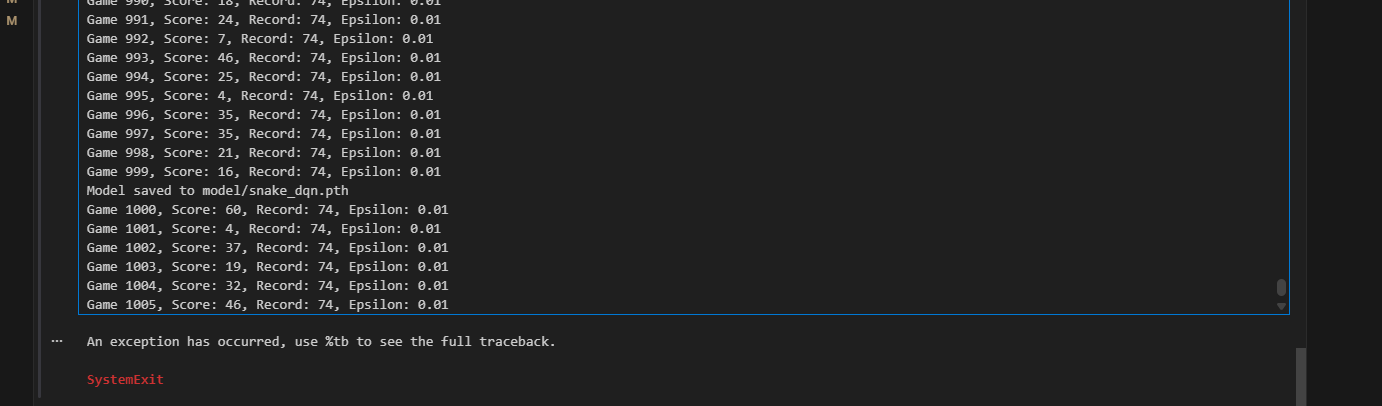